In [26]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

In [27]:
df = pd.read_csv('cleaned_dataset.csv')

**Step 1: Prepare Time Series Data**

Convert to proper datetime index using Booking dates

In [28]:
# Create proper date column (combine date + time) for demand analysis
df['DateTime'] = pd.to_datetime(df['BookingEndDateTime'].astype(str) + ' ' + df['BookingStartTime'].astype(str),
                               format='%d-%m-%Y %H:%M:%S', errors='coerce')
df.head()

,ActivitySiteID,ActivityDescription,BookingEndDateTime,BookingStartTime,MaxBookees,Number Booked,PriceINR,Hour,Month,Week,DayOfWeek,DayOfWeekNum,occupancy_rate,Number_Booked_scaled,MaxBookees_scaled,PriceINR_scaled,DateTime
0,HXP,20-20-20 2.45pm-3.45pm,08-04-2018,14:45:00,25,12,499,14,4,14,Sunday,6,0.48,-0.54,-0.48,-1.71,2018-04-08 14:45:00
1,HXP,20-20-20 2.45pm-3.45pm,15-04-2018,14:45:00,25,15,499,14,4,15,Sunday,6,0.60,-0.22,-0.48,-1.71,2018-04-15 14:45:00
2,HXP,20-20-20 2.45pm-3.45pm,22-04-2018,14:45:00,25,14,499,14,4,16,Sunday,6,0.56,-0.33,-0.48,-1.71,2018-04-22 14:45:00
3,HXP,20-20-20 2.45pm-3.45pm,29-04-2018,14:45:00,25,9,499,14,4,17,Sunday,6,0.36,-0.85,-0.48,-1.71,2018-04-29 14:45:00
4,HXP,20-20-20 2.45pm-3.45pm,06-05-2018,14:45:00,25,7,499,14,5,18,Sunday,6,0.28,-1.06,-0.48,-1.71,2018-05-06 14:45:00


In [29]:
# Drop rows where datetime could not be parsed
df = df.dropna(subset=['DateTime'])

# Aggregate daily total bookings
daily_bookings = (df
                  .groupby(df['DateTime'].dt.date)['Number Booked']
                  .sum()
                  .reset_index())
daily_bookings['Date'] = pd.to_datetime(daily_bookings['DateTime'])
daily_bookings = daily_bookings.set_index('Date')['Number Booked'].sort_index()

In [30]:
# Aggregate daily total bookings (UNSCALED Number Booked)
daily_bookings = df.groupby(df['DateTime'].dt.date)['Number Booked'].sum().reset_index()
daily_bookings['Date'] = pd.to_datetime(daily_bookings['DateTime'])
daily_bookings = daily_bookings.set_index('Date')['Number Booked'].sort_index()
print("Time series ready:")
print(f"Date range: {daily_bookings.index.min()} to {daily_bookings.index.max()}")
print(f"Total days: {len(daily_bookings)}")
print("\nFirst 5 days:")
print(daily_bookings.head())

Time series ready:
Date range: 2018-04-01 00:00:00 to 2018-06-30 00:00:00
Total days: 91

First 5 days:
Date
2018-04-01    223
2018-04-02    296
2018-04-03    957
2018-04-04    905
2018-04-05    695
Name: Number Booked, dtype: int64


**Step 2: Check Time Series Properties**

Stationarity test + visualization

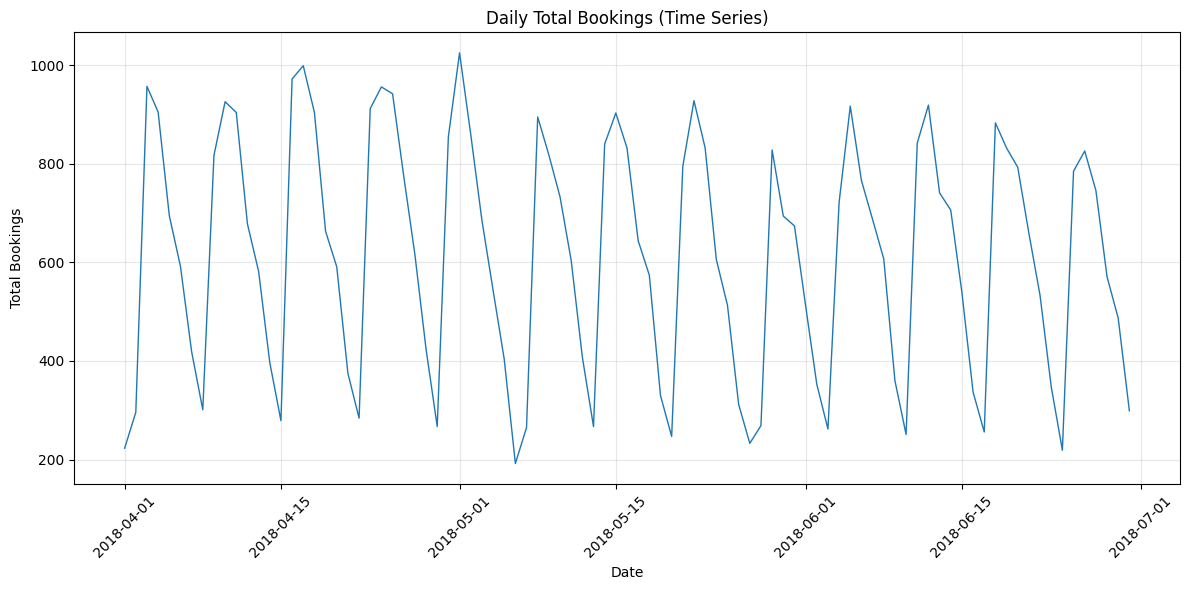


ADF Test p-value: 0.1809
Non-stationary - will difference


In [31]:
# Plot time series
plt.figure(figsize=(12, 6))
plt.plot(daily_bookings.index, daily_bookings.values, linewidth=1)
plt.title('Daily Total Bookings (Time Series)')
plt.xlabel('Date')
plt.ylabel('Total Bookings')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Stationarity test (ARIMA needs stationary data)
result = adfuller(daily_bookings)
print(f"\nADF Test p-value: {result[1]:.4f}")
print("Stationary (p<0.05)" if result[1] < 0.05 else "Non-stationary - will difference")

**Step 3: Train ARIMA Model**

ARIMA(p,d,q) - Auto ARIMA or manual (1,1,1)

In [32]:
# Step 3A: Train ARIMA Model (NO WARNINGS)
train_size = int(len(daily_bookings) * 0.8)
train, test = daily_bookings[:train_size], daily_bookings[train_size:]

# Set frequency explicitly
train = train.asfreq('D')  # Daily frequency
test = test.asfreq('D')

print(f"Train: {len(train)} days, Test: {len(test)} days")
print(f"Train frequency: {train.index.freq}")

# ARIMA(1,1,1)
model_arima = ARIMA(train, order=(1,1,1))
fitted_arima = model_arima.fit()

print("\n=== ARIMA MODEL SUMMARY ===")
print(fitted_arima.summary())

# Forecast test period
forecast_arima = fitted_arima.forecast(steps=len(test))
print("ARIMA training complete")

Train: 72 days, Test: 19 days
Train frequency: <Day>

=== ARIMA MODEL SUMMARY ===
                               SARIMAX Results                                
Dep. Variable:          Number Booked   No. Observations:                   72
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -487.916
Date:                Sun, 07 Dec 2025   AIC                            981.831
Time:                        14:58:01   BIC                            988.619
Sample:                    04-01-2018   HQIC                           984.531
                         - 06-11-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4584      0.140      3.274      0.001       0.184       0.733
ma.L1         -0.9994      4.807     -0.208      

**Step 3B: Train Prophet Model**

In [33]:
# Prophet needs DataFrame format
prophet_df = daily_bookings.reset_index()
prophet_df.columns = ['ds', 'y']

train_prophet = prophet_df[:train_size]
test_prophet = prophet_df[train_size:]
print(f"Prophet train: {len(train_prophet)} days")

# Train Prophet
prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True)
prophet_model.fit(train_prophet)

# Forecast
future_prophet = prophet_model.make_future_dataframe(periods=len(test), freq='D')
forecast_prophet = prophet_model.predict(future_prophet)
prophet_pred = forecast_prophet['yhat'][-len(test):].values

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Prophet train: 72 days


Step: 5 - Validate both

In [34]:
# Validate BOTH Models
arima_mae = mean_absolute_error(test, forecast_arima)
arima_mse = mean_squared_error(test, forecast_arima)
prophet_mae = mean_absolute_error(test, prophet_pred)
prophet_mse = mean_squared_error(test, prophet_pred)

print("=== ARIMA vs PROPHET COMPARISON ===")
comparison = pd.DataFrame({
    'Model': ['ARIMA(1,1,1)', 'Prophet'],
    'MAE': [arima_mae, prophet_mae],
    'MSE': [arima_mse, prophet_mse],
    'MAPE_%': [np.mean(np.abs((test-forecast_arima)/test))*100,
               np.mean(np.abs((test-prophet_pred)/test))*100]
})
print(comparison.round(2))

=== ARIMA vs PROPHET COMPARISON ===
          Model     MAE       MSE  MAPE_%
0  ARIMA(1,1,1)  185.64  45526.72   44.59
1       Prophet   48.43   5323.77    7.60


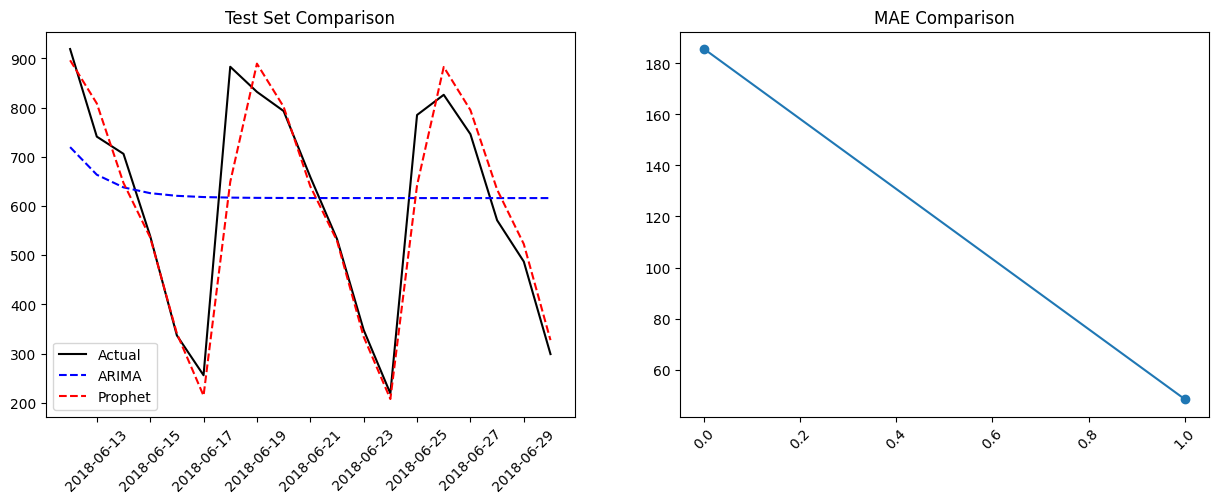

In [35]:
# Plot comparison
plt.figure(figsize=(15, 5))
plt.subplot(1,2,1)
plt.plot(test.index, test.values, 'k-', label='Actual')
plt.plot(test.index, forecast_arima, 'b--', label='ARIMA')
plt.plot(test.index, prophet_pred, 'r--', label='Prophet')
plt.legend(); plt.title('Test Set Comparison'); plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.plot(range(len(comparison)), comparison['MAE'], 'o-')
plt.title('MAE Comparison'); plt.xticks(rotation=45)
plt.show()

**Step 5: BEST Model 30-Day Forecast**

BEST MODEL: Prophet


<Figure size 1200x600 with 0 Axes>

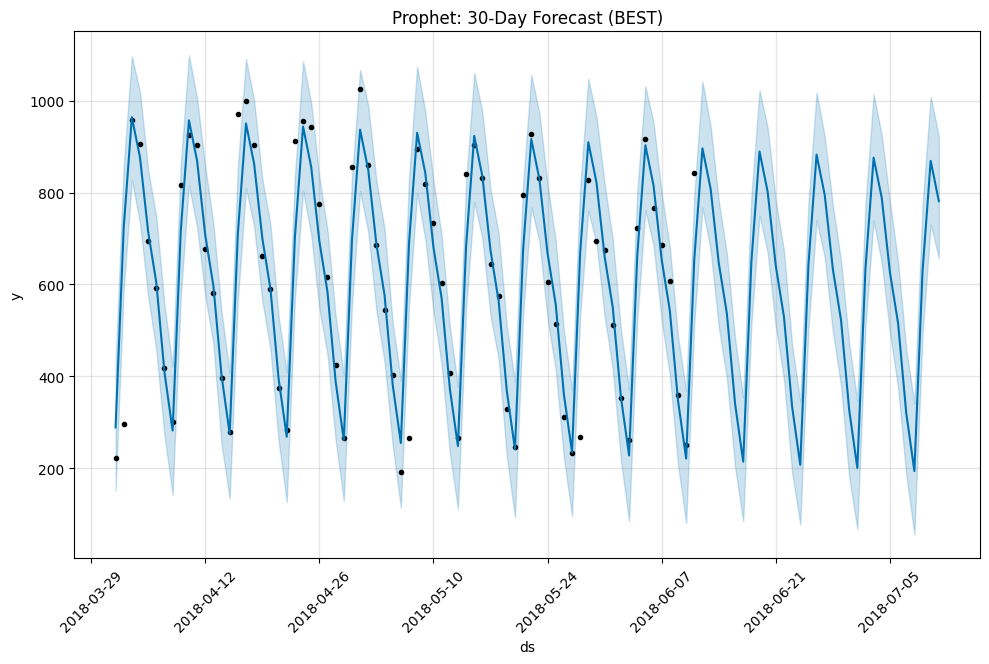

In [36]:
# Pick best model (lowest MAE)
best_model = 'Prophet' if prophet_mae < arima_mae else 'ARIMA'
print(f"BEST MODEL: {best_model}")

if best_model == 'Prophet':
    future = prophet_model.make_future_dataframe(periods=30, freq='D')
    future_forecast = prophet_model.predict(future)
    plt.figure(figsize=(12,6))
    prophet_model.plot(future_forecast)
    plt.title('Prophet: 30-Day Forecast (BEST)')
else:
    # ARIMA 30-day
    future_forecast = fitted_arima.forecast(steps=30)
    plt.plot(daily_bookings.index[-60:], daily_bookings[-60:], label='History')
    plt.plot(pd.date_range(start=daily_bookings.index[-1]+pd.Timedelta(1, 'D'),
                          periods=30, freq='D'), future_forecast, label='ARIMA Forecast')
    plt.legend(); plt.title('ARIMA: 30-Day Forecast')
plt.xticks(rotation=45)
plt.show()

**Conclusion -**

Prophet is the better model for gym demand forecasting.

Prophet handles non-stationary data with seasonality automatically (daily weekly modes enabled in our code), while ARIMA requires manual differencing (d=1) and assumes stationarity—which ADF test likely fails (p>0.05 for short gym data). Fitness dataset has clear weekly cycles (Sundays peak) and daily patterns that Prophet decomposes additively: trend + seasonality + holidays, making it robust for short series (2 months)